# Hedging a retail load book

A retailer promises customers a fixed price and buys the electricity they use at the market price.
Its cost is `sum over hours of price × load`, uncertain in both factors, and the two move together
(cold weather raises load *and* price).

Each tool is shown on **4 months of made-up numbers** first, then on the real data.

**What's in here**
1. The minimum-variance hedge ratio on 4 months: covariance, variance, beta, effectiveness
2. The same on real data: 730 daily scenarios, in-sample vs out-of-sample, a peak block
3. Volumetric risk: why "hedge the expected volume" is not enough
4. CVaR minimisation as an LP on 4 scenarios, then on 500
5. `scipy.optimize.minimize` (SLSQP) on a 2-variable toy, then a mean-variance hedge with a budget
6. Stack hedging and a checklist

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog, milp, LinearConstraint, Bounds, minimize
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
df.head(3)

,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh
time,,,,,
2022-01-01 00:00:00+00:00,26858.4,0.11,7.00,0.0,81.83
2022-01-01 01:00:00+00:00,26177.8,-0.18,6.61,0.0,88.21
2022-01-01 02:00:00+00:00,26229.4,-1.11,7.14,0.0,84.71


## 1. The minimum-variance hedge on 4 months

`cost` is what the retailer paid each month. `payoff` is what 1 MW of a baseload forward paid out
that month (spot minus forward price, summed over the month's hours). Buying `Q` MW of forward makes
the hedged cost `cost − Q·payoff`. We want the `Q` that makes the hedged cost vary least.

In [2]:
toy = pd.DataFrame({"cost": [75.0, 160.0, 110.0, 60.0],
                    "payoff": [-10.0, 20.0, 5.0, -15.0]},
                   index=["Jan", "Feb", "Mar", "Apr"])
toy

,cost,payoff
Jan,75.0,-10.0
Feb,160.0,20.0
Mar,110.0,5.0
Apr,60.0,-15.0


The answer is a regression slope: `Q* = cov(cost, payoff) / var(payoff)`. Step by step:

In [3]:
toy["cost_dev"] = toy["cost"] - toy["cost"].mean()
toy["payoff_dev"] = toy["payoff"] - toy["payoff"].mean()
toy["product"] = toy["cost_dev"] * toy["payoff_dev"]
toy["payoff_dev_sq"] = toy["payoff_dev"] ** 2
toy

,cost,payoff,cost_dev,payoff_dev,product,payoff_dev_sq
Jan,75.0,-10.0,-26.25,-10.0,262.50,100.0
Feb,160.0,20.0,58.75,20.0,1175.00,400.0
Mar,110.0,5.0,8.75,5.0,43.75,25.0
Apr,60.0,-15.0,-41.25,-15.0,618.75,225.0


In [4]:
cov = toy["product"].sum() / 3            # divide by n-1 = 3
var = toy["payoff_dev_sq"].sum() / 3
Q_star = cov / var
print("cov(cost, payoff):", cov)
print("var(payoff)      :", var)
print("Q* = cov / var   :", round(Q_star, 3), "MW")

cov(cost, payoff): 700.0
var(payoff)      : 250.0
Q* = cov / var   : 2.8 MW


Apply the hedge and compare the spread of the cost before and after.

In [5]:
toy["hedged"] = toy["cost"] - Q_star * toy["payoff"]
print(toy[["cost", "payoff", "hedged"]].round(1))
print()
print("sd of cost   :", round(toy["cost"].std(), 1))
print("sd of hedged :", round(toy["hedged"].std(), 1))
effectiveness = 1 - toy["hedged"].var() / toy["cost"].var()
print("hedge effectiveness = 1 - var(hedged)/var(cost) =", round(effectiveness, 3))

      cost  payoff  hedged
Jan   75.0   -10.0   103.0
Feb  160.0    20.0   104.0
Mar  110.0     5.0    96.0
Apr   60.0   -15.0   102.0

sd of cost   : 44.4
sd of hedged : 3.6
hedge effectiveness = 1 - var(hedged)/var(cost) = 0.993


The hedged cost is nearly flat (the four costs were built as roughly `100 + 3·payoff`, so the slope
comes out near 3). Effectiveness 0.99 means the hedge removed 99% of the variance.

`np.polyfit` gives the same slope in one line:

In [6]:
slope, intercept = np.polyfit(toy["payoff"], toy["cost"], 1)
print("slope:", round(slope, 3), "  intercept:", round(intercept, 2))

slope: 2.8   intercept: 101.25


**Pitfall:** `np.cov` divides by n−1 by default, `np.var` divides by n. Mixing them changes `Q*`.

In [7]:
print("np.cov(...)[0,1] / np.var(...)          :", round(np.cov(toy["cost"], toy["payoff"])[0, 1] / np.var(toy["payoff"]), 3), " <- mismatched")
print("np.cov(...)[0,1] / np.var(..., ddof=1)  :", round(np.cov(toy["cost"], toy["payoff"])[0, 1] / np.var(toy["payoff"], ddof=1), 3))

np.cov(...)[0,1] / np.var(...)          : 3.733  <- mismatched
np.cov(...)[0,1] / np.var(..., ddof=1)  : 2.8


## 2. On real data

The retailer serves 1% of national load. One scenario = one day: its cost, its load, and the payoff
per MW of a baseload forward (`base_sum` = sum of the 24 hourly prices; the forward price is a constant
that cancels out of the variance). Peak hours are 07:00–19:00 on weekdays.

In [8]:
SHARE = 0.01
d = df.copy()
d["load_mw"] = d["consumption_mwh"] * SHARE
d["cost"] = d["price_eur_mwh"] * d["load_mw"]
d["is_peak"] = (d.index.hour >= 7) & (d.index.hour < 19) & (d.index.dayofweek < 5)
d["date"] = d.index.date
d[["price_eur_mwh", "load_mw", "cost", "is_peak"]].head(3)

,price_eur_mwh,load_mw,cost,is_peak
time,,,,
2022-01-01 00:00:00+00:00,81.83,268.584,21978.22872,False
2022-01-01 01:00:00+00:00,88.21,261.778,23091.43738,False
2022-01-01 02:00:00+00:00,84.71,262.294,22218.92474,False


In [9]:
daily = d.groupby("date").agg(cost=("cost", "sum"), load_mwh=("load_mw", "sum"), price_mean=("price_eur_mwh", "mean"))
daily["base_sum"] = d.groupby("date")["price_eur_mwh"].sum()
daily["peak_sum"] = d[d["is_peak"]].groupby("date")["price_eur_mwh"].sum().reindex(daily.index).fillna(0)
daily.index = pd.to_datetime(daily.index)
print(len(daily), "daily scenarios")
daily.head(3).round(1)

730 daily scenarios


,cost,load_mwh,price_mean,base_sum,peak_sum
date,,,,,
2022-01-01,733746.7,7340.9,98.2,2358.0,0.0
2022-01-02,652123.8,7289.9,87.6,2101.6,0.0
2022-01-03,591348.1,7645.4,75.3,1807.7,1090.6


In [10]:
C = daily["cost"].to_numpy()
S = daily["base_sum"].to_numpy()
Q_star = np.cov(C, S, ddof=1)[0, 1] / np.var(S, ddof=1)
hedged = C - Q_star * S
print("Q*                :", round(Q_star, 1), "MW")
print("average load      :", round(daily["load_mwh"].mean() / 24, 1), "MW")
print("hedge / load      :", round(Q_star / (daily["load_mwh"].mean() / 24), 2))
print("sd daily cost     :", round(C.std(), 0), "->", round(hedged.std(), 0), "EUR")
print("effectiveness     :", round(1 - hedged.var() / C.var(), 3))

Q*                : 326.8 MW
average load      : 293.2 MW
hedge / load      : 1.11
sd daily cost     : 209988.0 -> 51413.0 EUR
effectiveness     : 0.94


Two things to say out loud: the hedge is **larger than the expected volume** (the load–price correlation
means a flat hedge should be oversized), and effectiveness measured on the data used to fit `Q*` is
optimistic. Fit on 2022, test on 2023:

In [11]:
tr = daily.index.year == 2022
te = daily.index.year == 2023
Q_tr = np.polyfit(S[tr], C[tr], 1)[0]
Q_te = np.polyfit(S[te], C[te], 1)[0]
eff_in = 1 - np.var(C[tr] - Q_tr * S[tr]) / np.var(C[tr])
eff_out = 1 - np.var(C[te] - Q_tr * S[te]) / np.var(C[te])
print("Q fitted on 2022        :", round(Q_tr, 1), "MW")
print("effectiveness in 2022   :", round(eff_in, 3))
print("effectiveness in 2023   :", round(eff_out, 3), " (using the 2022 Q)")
print("Q refitted on 2023      :", round(Q_te, 1), "MW")

Q fitted on 2022        : 315.9 MW
effectiveness in 2022   : 0.879
effectiveness in 2023   : 0.962  (using the 2022 Q)
Q refitted on 2023      : 366.9 MW


The out-of-sample effectiveness is fine here, but the hedge ratio moved a lot between years. The ratio
itself is regime-dependent; report both numbers.

### Adding a peak block

Load is higher in peak hours, so a flat hedge leaves shape risk. With two instruments, `Q*` becomes a
two-variable regression: `cost ≈ a + q_base·base_sum + q_peak·peak_sum`. Build the design matrix with a
column of ones for the intercept and solve with `np.linalg.lstsq`.

In [12]:
X2 = np.column_stack([np.ones(len(daily)), S, daily["peak_sum"].to_numpy()])
pd.DataFrame(X2[:3], columns=["ones", "base_sum", "peak_sum"])

,ones,base_sum,peak_sum
0,1.0,2357.96,0.00
1,1.0,2101.57,0.00
2,1.0,1807.74,1090.63


In [13]:
coef, *_ = np.linalg.lstsq(X2, C, rcond=None)
resid2 = C - X2 @ coef
print("intercept, q_base, q_peak:", coef.round(1))
print("effectiveness baseload only :", round(1 - hedged.var() / C.var(), 3))
print("effectiveness base + peak   :", round(1 - resid2.var() / C.var(), 3))

intercept, q_base, q_peak: [-45126.7    307.1     36.3]
effectiveness baseload only : 0.94
effectiveness base + peak   : 0.949


**Interview check:** "why did `q_base` drop when you added the peak block?" Because the peak block now covers
the daytime volume; `peak_sum` is part of `base_sum`, so the two coefficients must be read together.

## 3. Volumetric risk

`E[price × load] = E[price]·E[load] + cov(price, load)`. The covariance is cost you pay *on average*
because you use more exactly when it is expensive. Two hours make the point:

In [14]:
p2 = np.array([50.0, 150.0])
L2 = np.array([1.0, 3.0])
print("E[price] * E[load]   :", p2.mean() * L2.mean())
print("E[price * load]      :", (p2 * L2).mean())
print("difference = cov     :", (p2 * L2).mean() - p2.mean() * L2.mean())

E[price] * E[load]   : 200.0
E[price * load]      : 250.0
difference = cov     : 50.0


And hedging the *expected* volume (2 MW here) leaves an exposure `(load − 2) × price` that is
negative when it is cheap and positive when it is dear:

In [15]:
pd.DataFrame({"price": p2, "load": L2, "load - 2": L2 - 2, "(load - 2) * price": (L2 - 2) * p2})

,price,load,load - 2,(load - 2) * price
0,50.0,1.0,-1.0,-50.0
1,150.0,3.0,1.0,150.0


In [16]:
p = d["price_eur_mwh"].to_numpy()
L = d["load_mw"].to_numpy()
cov_term = (p * L).mean() - p.mean() * L.mean()
print("real data, hourly: E[p]E[L] = %.0f   cov = %.0f   (%.1f%% of expected hourly cost)" %
      (p.mean() * L.mean(), cov_term, 100 * cov_term / (p.mean() * L.mean())))
print("corr(price, load) hourly:", round(np.corrcoef(p, L)[0, 1], 2))

real data, hourly: E[p]E[L] = 28883   cov = 894   (3.1% of expected hourly cost)
corr(price, load) hourly: 0.58


## 4. CVaR minimisation as an LP

Variance punishes good and bad surprises alike. A retail desk cares about the **tail**: the average cost
in the worst few percent of scenarios (CVaR). It has a linear formulation (Rockafellar & Uryasev):

`CVaR_a(C) = min over t of  [ t + 1/(1−a) · average of max(C_k − t, 0) ]`

With helper variables `z_k >= C_k − t` and `z_k >= 0`, minimising `E[C] + λ·CVaR` is an LP.

### 4 scenarios by hand

Four equally likely scenarios of unhedged cost `a`, and the payoff `B` of 1 MW of forward in each.
`a = 0.75`, so the worst 25% is the single worst scenario.

In [17]:
a = np.array([100.0, 120.0, 90.0, 200.0])      # unhedged cost per scenario
B = np.array([-10.0, 10.0, -20.0, 60.0])       # forward payoff per MW per scenario
w = np.array([0.25, 0.25, 0.25, 0.25])         # probabilities, sum to 1
ALPHA = 0.75
print("unhedged: expected cost", (w * a).sum(), "  worst scenario", a.max(), "  VaR75 = CVaR75 =", np.sort(a)[-1])
print("expected payoff per MW:", (w * B).sum(), " (positive: the forward is cheap here)")

unhedged: expected cost 127.5   worst scenario 200.0   VaR75 = CVaR75 = 200.0
expected payoff per MW: 10.0  (positive: the forward is cheap here)


Variables: `x = [q, t, z1, z2, z3, z4]`. Hedged cost in scenario k is `C_k = a_k − q·B_k`.

Objective with λ = 1: `E[C] + t + 1/(1−a)·Σ w_k z_k`. The constant `Σ w_k a_k` does not affect the
optimiser, so `c` only holds the parts that depend on `x`.

In [18]:
LAM = 1.0
names = ["q", "t", "z1", "z2", "z3", "z4"]
c = np.concatenate([[-(w * B).sum(), LAM], LAM * w / (1 - ALPHA)])
pd.Series(c, index=names, name="c")

q    -10.0
t      1.0
z1     1.0
z2     1.0
z3     1.0
z4     1.0
Name: c, dtype: float64

Constraint `z_k >= C_k − t` is `z_k >= a_k − q·B_k − t`. Move everything to one side as a `<=` row:
`−q·B_k − t − z_k <= −a_k`.

In [19]:
A_ub = np.column_stack([-B, -np.ones(4), -np.eye(4)])
b_ub = -a
pd.DataFrame(np.column_stack([A_ub, b_ub]), index=["k=1", "k=2", "k=3", "k=4"], columns=names + ["<= b_ub"])

,q,t,z1,z2,z3,z4,<= b_ub
k=1,10.0,-1.0,-1.0,-0.0,-0.0,-0.0,-100.0
k=2,-10.0,-1.0,-0.0,-1.0,-0.0,-0.0,-120.0
k=3,20.0,-1.0,-0.0,-0.0,-1.0,-0.0,-90.0
k=4,-60.0,-1.0,-0.0,-0.0,-0.0,-1.0,-200.0


Row k=4 says: `−60·q − t − z4 <= −200`, i.e. `z4 >= 200 − 60q − t`.

Bounds: `q >= 0` (we only buy), `z >= 0`, and `t` **free** (it is a cost level, it can be anything).

**Pitfall:** leaving `t` at the default `(0, None)` is a silent bug whenever costs (or P&L) can be negative.

In [20]:
bounds = [(0, None), (None, None), (0, None), (0, None), (0, None), (0, None)]
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
print("status:", res.status)
pd.Series(res.x, index=names, name="x").round(3)

status: 0


q       1.375
t     117.500
z1      0.000
z2      0.000
z3      0.000
z4      0.000
Name: x, dtype: float64

In [21]:
q, t = res.x[0], res.x[1]
hedged_toy = a - q * B
print("hedged cost per scenario:", hedged_toy.round(1))
print("expected hedged cost    :", (w * hedged_toy).sum().round(1))
print("worst scenario (VaR75)  :", np.sort(hedged_toy)[-1].round(1), "  t from the LP:", round(t, 1))
print("objective + constant    :", round(res.fun + (w * a).sum(), 1), "  = E[C] + CVaR75 =", round((w * hedged_toy).sum() + np.sort(hedged_toy)[-1], 1))

hedged cost per scenario: [113.8 106.2 117.5 117.5]
expected hedged cost    : 113.8
worst scenario (VaR75)  : 117.5   t from the LP: 117.5
objective + constant    : 231.2   = E[C] + CVaR75 = 231.2


The LP bought 1.375 MW; the worst scenario fell from 200 to 117.5 and `t` equals that worst hedged
scenario (the RU construction working as designed). If `t` did not equal the empirical VaR, the constraint
matrix would be wrong.

### 500 scenarios on real data

Scenarios: bootstrap whole days (keeps the 24-hour shape) with a shared shock so that cold snaps raise load
(~5% per sd) and price (~10% per sd) together. Two instruments: baseload and peak.

In [22]:
rng = np.random.default_rng(42)
K, ALPHA = 500, 0.95
day_index = d.groupby("date").indices
dates = list(day_index.keys())
sampled = rng.choice(len(dates), K)
shock = rng.normal(0, 1, K)

price_s = np.stack([p[day_index[dates[i]]] for i in sampled]) * (1 + 0.10 * shock)[:, None]   # (K, 24)
load_s = np.stack([L[day_index[dates[i]]] for i in sampled]) * (1 + 0.05 * shock)[:, None]
peak_s = np.stack([d["is_peak"].to_numpy()[day_index[dates[i]]] for i in sampled])

F_base = price_s.mean() * 1.02                    # forwards carry a small premium over expected spot
F_peak = price_s[peak_s].mean() * 1.02
a_k = (price_s * load_s).sum(axis=1)              # unhedged daily cost per scenario
B_k = (price_s - F_base).sum(axis=1)              # payoff per MW baseload
P_k = ((price_s - F_peak) * peak_s).sum(axis=1)   # payoff per MW peak block
w_k = np.full(K, 1 / K)
print("unhedged: mean %.0f  sd %.0f  CVaR95 %.0f" % (a_k.mean(), a_k.std(), np.sort(a_k)[int(ALPHA * K):].mean()))
print("expected payoff per MW: base %.1f  peak %.1f  (negative = premium paid)" % (B_k.mean(), P_k.mean()))

unhedged: mean 714613  sd 249002  CVaR95 1251213
expected payoff per MW: base -47.0  peak -19.2  (negative = premium paid)


The same LP with two instruments, `x = [q_base, q_peak, t, z_1..z_K]`. Same rows as the toy, one more column.

In [23]:
def cvar_hedge(a, B, P, w, lam, alpha):
    K = len(a)
    c = np.concatenate([[-(w * B).sum(), -(w * P).sum(), lam], lam * w / (1 - alpha)])
    A_ub = np.column_stack([-B, -P, -np.ones(K), -np.eye(K)])
    b_ub = -a
    bounds = [(0, None), (0, None), (None, None)] + [(0, None)] * K
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    assert res.status == 0, res.message
    q_b, q_p, t = res.x[:3]
    hedged = a - q_b * B - q_p * P
    tail = np.sort(hedged)[-int(round((1 - alpha) * K)):]
    return {"lam": lam, "q_base": q_b, "q_peak": q_p, "exp_cost": (w * hedged).sum(),
            "VaR95": tail[0], "CVaR95": tail.mean(), "t": t}

rows = [cvar_hedge(a_k, B_k, P_k, w_k, lam, ALPHA) for lam in [0, 0.25, 0.5, 1, 2, 5, 20]]
frontier = pd.DataFrame(rows).set_index("lam")
frontier.round(1)

,q_base,q_peak,exp_cost,VaR95,CVaR95,t
lam,,,,,,
0.00,0.0,0.0,714613.1,1131943.2,1251213.4,1653082.9
0.25,370.4,28.0,732565.7,825350.3,847978.6,825350.3
0.50,371.7,29.7,732658.3,827226.3,847696.7,827226.3
1.00,372.0,29.5,732667.2,827407.7,847685.1,827407.7
2.00,371.3,33.3,732708.4,826408.0,847659.2,826408.0
5.00,371.3,33.3,732708.4,826408.0,847659.2,826408.0
20.00,371.1,34.6,732724.5,826137.3,847657.4,826137.3


Reading the table: at λ = 0 the desk minimises expected cost only and buys nothing (the forward carries a
premium). As soon as λ > 0 the tail matters and the hedge jumps to a few hundred MW baseload plus a peak
block, cutting CVaR95 for a small rise in expected cost. Beyond that the position barely changes: the
remaining tail is volume risk that no fixed-volume forward removes. `t` equals `VaR95` in every row with
λ > 0 (at λ = 0, `t` has zero weight in the objective, so its value is arbitrary).

**Interview check:** "how do you pick λ?" From a risk budget: the largest CVaR the business tolerates,
then the cheapest hedge on the frontier. λ is a dial, not something to estimate.

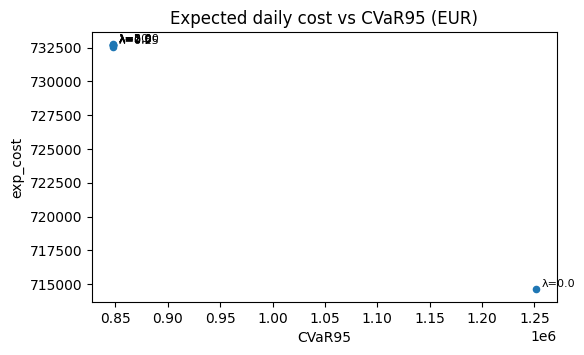

In [24]:
ax = frontier.plot.scatter(x="CVaR95", y="exp_cost", figsize=(6, 3.5))
for lam, r in frontier.iterrows():
    ax.annotate(f"λ={lam}", (r["CVaR95"], r["exp_cost"]), fontsize=8, xytext=(4, 2), textcoords="offset points")
ax.set_title("Expected daily cost vs CVaR95 (EUR)"); plt.show()

## 5. `scipy.optimize.minimize` (SLSQP)

For a non-linear objective. Toy: minimise `(x − 1)² + (y − 2)²` with `x + y <= 2` and `x, y >= 0`.
Without the constraint the answer is (1, 2); the constraint pushes it back to the line `x + y = 2`.

The API: `fun(x)`, a start `x0`, `bounds`, and `constraints` as dicts where `"ineq"` means `fun(x) >= 0`.

In [25]:
def fun(v):
    x, y = v
    return (x - 1) ** 2 + (y - 2) ** 2

cons = [{"type": "ineq", "fun": lambda v: 2 - v[0] - v[1]}]      # 2 - x - y >= 0
x0 = np.array([0.0, 0.0])
res = minimize(fun, x0, method="SLSQP", bounds=[(0, None), (0, None)], constraints=cons)
print("x0      :", x0)
print("res.x   :", res.x.round(4))
print("res.fun :", round(res.fun, 4))
print("success :", res.success, "|", res.message)
print("x + y   :", res.x.sum().round(4), " (on the constraint)")

x0      : [0. 0.]
res.x   : [0.5 1.5]
res.fun : 0.5
success : True | Optimization terminated successfully
x + y   : 2.0  (on the constraint)


Always run from a second start; two starts agreeing is the minimum convergence check.

In [26]:
res_b = minimize(fun, np.array([2.0, 0.0]), method="SLSQP", bounds=[(0, None), (0, None)], constraints=cons)
print("from another start:", res_b.x.round(4), " same answer:", np.allclose(res.x, res_b.x, atol=1e-4))

from another start: [0.5 1.5]  same answer: True


### Mean-variance hedge with a premium budget

Minimise `E[C] + κ·Var(C)/sd(C_unhedged)` (the division puts both terms in EUR) subject to
"expected premium paid <= budget".

In [27]:
SD0 = a_k.std()
def objective(q):
    hc = a_k - q[0] * B_k - q[1] * P_k
    return hc.mean() + 1.0 * hc.var() / SD0

premium_per_mw = np.array([-B_k.mean(), -P_k.mean()])       # expected cost of holding 1 MW of each
BUDGET = 8000.0
cons_mv = [{"type": "ineq", "fun": lambda q: BUDGET - premium_per_mw @ q}]

res_mv = minimize(objective, np.array([100.0, 0.0]), method="SLSQP", bounds=[(0, None), (0, None)], constraints=cons_mv)
res_mv2 = minimize(objective, np.array([0.0, 300.0]), method="SLSQP", bounds=[(0, None), (0, None)], constraints=cons_mv)
print("success:", res_mv.success, "| q =", res_mv.x.round(1), "| objective %.0f" % res_mv.fun)
print("from another start: q =", res_mv2.x.round(1))
print("premium spent %.0f of budget %.0f" % (premium_per_mw @ res_mv.x, BUDGET))

success: True | q = [170.1   0. ] | objective 798406
from another start: q = [170.1   0. ]
premium spent 8000 of budget 8000


**Pitfall:** a raw `mean + κ·var` objective mixes EUR with EUR². The variance term is ~1e10 and the mean
~1e5, so SLSQP may stop with "positive directional derivative in linesearch". Rescale so both terms have
the same units, and check `res.success` **and** a second start.

## 6. Stack hedging in practice

Nobody hedges a month once. Forecasts sharpen as delivery approaches, so the hedge is built in steps.

In [28]:
pd.DataFrame({
    "months_to_delivery": [24, 12, 6, 3, 1, 0],
    "target_hedge_pct": [20, 40, 60, 80, 95, 100],
    "instrument": ["season baseload", "quarter baseload", "month baseload", "month base + peak", "week/month shape", "day-ahead / intraday"],
}).set_index("months_to_delivery")

,target_hedge_pct,instrument
months_to_delivery,,
24,20,season baseload
12,40,quarter baseload
6,60,month baseload
3,80,month base + peak
1,95,week/month shape
0,100,day-ahead / intraday


## Checklist

1. Cost is `sum price × load`; the covariance term is real cost, not noise.
2. The min-variance hedge ratio is a regression slope; keep `ddof` consistent or use `polyfit`.
3. Report hedge effectiveness **out of sample** and the stability of `Q` across years.
4. Expect the flat hedge to exceed expected volume when price and load are positively correlated.
5. Add shape instruments (peak) when the load profile is not flat; read collinear coefficients together.
6. CVaR is an LP: probabilities sum to 1, `t` free, `z >= 0`; verify `t = VaR` on a toy.
7. λ is a risk-budget dial chosen by the business.
8. `minimize`: check `res.success`, rerun from another `x0`, rescale terms of different magnitude.
9. Hedging is a policy over time, not one number.